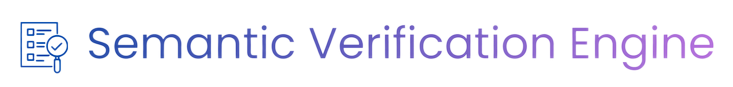

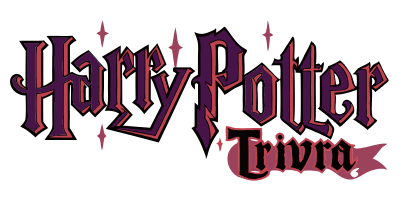

<div style="background-color: #f0e6f7; padding: 7px;">
    <h3 style="text-align:center; color:purple;">Tracer: Synthetic Data Validation</h3>
</div>

## 1: Executive Summary

### 1.1. System overview 
This notebook is part of the initial **Tracer Build** of the **Semantic Verification Engine (SVE)**, demonstrating the core runtime logic through a *Harry Potter trivia game* reference implementation. 

The goal here is to use the constrained trivia domain to demonstrate what a **production-style semantic evaluation system looks like when designed and validated under real engineering constraints**. The focus is less on the game itself and more on how data validation, enrichment, and integrity are handled when approached with that level of rigor.

The system evaluates player answers based on *semantic correctness* while maintaining *low latency, CPU-only execution, and deterministic behavior*. To satisfy these constraints without sacrificing reasoning depth, the architecture adopts a *“shift intelligence left”* strategy: 
> **All complex semantic processing is performed offline, leaving runtime execution lightweight, predictable, and fast.** 

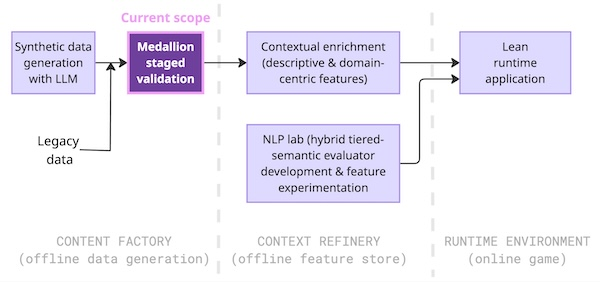

<p>
  <em>
    <b>Figure-1:</b> high-level scheme of the SVE architecture. The highlighted section reflects the scope of this notebook.<br>
    <small>Note: Legacy data refers to validated & corrected Hugging Face dataset from the project discovery phase.</small>
  </em>
</p>

The design philosophy, as a result, follows a top-down architecture design in (refer to [design doc](../../../docs/00_DESIGN_DOC_AND_ARCHITECTURE.md) for more details).

#### Offline Subsystems (semantic preparation layer)

The offline subsystems are responsible for constructing a **fully validated semantic payload** ahead of runtime. This includes:
- **Content generation & enrichment** produce high-quality synthetic questions enriched with core lore concepts, source and entities references grounded in source text.
- **Multi-stage validation (medallion architecture)** An adapted medallion pattern (Bronze → Silver → Gold) standardizes, validates (RAG-Triad + semantic deduplication), and distills content into lightweight, runtime-ready semantic payloads. 
- **Semantic precomputation**: Generate SBERT embeddings and other reusable signals for runtime evaluation.
- **Knowledge packaging**: prebuilding structured hints and explanations to eliminate need for repetitive LLM calls during gameplay.

#### Runtime Engine (lean evaluation layer) 
At runtime, the system operates exclusively on the prevalidated dataset to ensure **predictable latency**, **traceable decision paths**, and **robust, error-resistant execution** by: 
- deterministic routing and modular evaluators.
- The core game flow does not require LLM, and it is used only for edge-case resolution.
<br>

### 1.2: Current scope

This notebook walks through the medallion-inspired lifecycle, augmented with a semantic QA layer, which transforms raw LLM outputs into a runtime-certified evaluation dataset. The QA Validation Pipeline is the first semantic intelligence layer in the SVE system, where embeddings and LLM-based validation are introduced.

*Note on execution context before walking through the workflow:*
During initial system bootstrap, the validated Legacy dataset is promoted first to establish the Silver and Gold datasets. After which validated synthetic batches are appended to preserve legacy precedence. The notebook workflow demonstrates the standard path for a synthetic batch once the main datasets are in place.

#### Schema-driven medallion workflow
The worfklow processes a synthetic batch through a simplified version of a production-style validation pipeline:

**Bronze → QA Validation Pipeline → Silver Gate → Gold Gate**

1. Raw LLM outputs (unvalidated, potentially duplicated, semantically unverified) are ingested into the QA Validation Pipeline.

2. The data undergoes multi-layer validation:

    - [**Stage 1 — Structural validation**](#stage-1-structural-validation)  
      Enforce the Bronze Pydantic schema, normalize columns, and validate structural integrity.

    - [**Stage 2 — Semantic integrity checks**](#stage-2-deduplication--contextual-integrity-checks)  
      Centrally precompute embeddings for both validation and downstream systems. Detect cross-question type duplicates within the batch using SBERT similarity graphs. Validate contextual grounding using RAG-Triad-inspired LLM checks.

    - [**Stage 3 — Alignment**](#stage-3-alignment)  
      Validate gameplay enrichment fields (answer_variations, hints, MCQ distractors, explanations) against canonical answers and question intent.

    - [**Stage 4 — Promotion preparation**](#stage-4-promotion-preparation)  
      Second stage deduplication of the  batch against the main Silver dataset. Assign persistent system identifier(`master_id`).

3. [**Silver-tier promotion**](#5-silver-tier-promotion)
   Promote  with Silver Pydantic gate and append batch to the main Silver dataset. Silver retains full lineage, including embeddings, validation traces, and metadata required for debugging and origin tracking.

4. [**Gold-tier promotion**](#6-gold-tier-promotion)  
   Gold is derived from the full Silver dataset through the Gold Pydantic gate. It represents a stripped, runtime-ready projection of Silver used by downstream systems (Context Refinery and gameplay engine). No direct batch promotion occurs into Gold.

### 1.3: Validation Yield
Final Silver promotion yield: **35 / 50 questions retained (70%)**. The table below shows the breakdown by pipeline stage:

| Stage | Validation Check | Passed | Failed / Dropped |
|---|---|---|---|
| 1 | Structural validation (Pydantic) | 50 | 0 |
| 2 | Batch Deduplication | 44 | 6 |
| 2 | Contextual integrity (RAG-Triad) | 42 | 2 |
| 3 | Alignment — answer variations | 38 | 4 |
| 3 | Alignment — MCQ options | 37 | 1 |
| 3 | Alignment — LLM categorization | 36 | 1 |
| 3 | Alignment — hints & explanations | 36 | 0 |
| 4 | Canonical deduplication (against Silver dataset)|35|1|

The validation pipeline is conservative and prioritizes safety over recall. It is tuned to minimize false positives in the Silver dataset even if it risks rejecting borderline cases.

Problematic rows are generally dropped during the Tracer phase when they reflect core semantic or structural failures in the question–answer pair. However, enrichment-only issues (e.g. answer variations, hints, explanations) may be corrected in-place when the underlying record remains valid. Synthetic generation is comparatively inexpensive, while semantic correction introduces additional human intervention, review complexity, and provenance considerations. As a result, the system prioritizes regeneration for invalid core records and targeted correction for low-cost enrichment issues. More sophisticated salvage or repair strategies may be explored later if generation cost, throughput requirements, or domain constraints justify additional complexity.

**Generation pipeline performance**: Despite the relatively strict filtering, the overall synthetic generation quality is strong. Most generated questions are correctly grounded in the source material and the observed failures are primarily caused by:
- duplicate generation,
- minor embellishments,
- or structural inconsistencies in enrichment fields.

This shows that the generation pipeline is effective with opportunities for prompt refinement, threshold calibration, and upstream optimization.

**Validation pipeline performance**: The results confirm the need for the semantic QA validation layers. Each validation stage surfaced failure modes. It confirms that raw LLM cannot simply be served directly at runtime, even for a constrained domain like Harry Potter trivia.

### 1.4: Known limitations & planned mitigations

- **Fragmented answer variations for FR/MCQ:** some generated answer variations incorrectly split full answers into partial fragments. This can introduce ambiguity in downstream evaluation and requires tighter structural constraints in generation prompts.
- **Heuristic question–answer alignment checks:** current alignment validation between `question_type`, answer structure, and LLM-assigned categories relies on empirical rule-based heuristics. Future iterations should introduce more deterministic validation logic and stronger structural typing.
- **Tracer-tuned semantic thresholds:** deduplication and alignment thresholds were calibrated for the current legacy + synthetic tracer dataset. Additional batch testing is required to ensure robustness across larger, diverse generation runs.
- **No dedicated spell check:** The tracer preprocessing uses lightweight normalization and does not include spell correction. A misspelled answer variation was observed (and indirectly removed during contextual integrity filtering), indicating that spell checks may be worth evaluating further.
- **Hydration layer for storage reads:** To maintain separation of concerns, a dedicated `load_silver_parquet` hydration step should be introduced to convert Parquet data into Python-native structures before pipeline entry. This ensures Pydantic is used strictly for schema validation and invariant enforcement. This separation also improves performance, as row-wise Pydantic validation is not well-suited to orchestrated batch processing.
 - **Embedding normalization:** not required in the Tracer since cosine similarity is used consistently across all evaluation stages. It becomes relevant only if the similarity metric is changed (e.g. dot product or Euclidean distance) or if embeddings are used in downstream systems such as clustering or vector database-based retrieval (ANN indexing), where scale sensitivity affects behavior.

### 1.5: Next steps

- **Defined operating envelope for pipeline**: When orchestrated, the pipeline will need to operate within empirically derived constraints to maintain data quality. Validation quality is affected by batch configuration. LLM judge consistency and scoring stability vary depending on how samples are grouped and batched. Observed effects include:
  - reduced judge consistency at larger batch sizes,
  - improved stability when grouping by question type,
  - improved grounding when limiting source context to ~2 chapters per call.
- **Scaling of contextual integrity and gameplay alignment checks** currently use a high-reasoning LLM judge for full tracer evaluation. Future work should explore lower cost or hybrid approaches for long-term scalability.

#### Imports and setup

In [1]:
#  STANDARD NOTEBOOK SETUP
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')
# --- Core Libraries ---
import json
import pyarrow.parquet as pq
import warnings
import pandas as pd
from IPython.display import display
# --- Project-Specific Imports ---
from core.embeddings import get_sbert_model
import notebook_support.notebook_config as nb_cfg
from notebook_support.ds_constants import DataTier,  QuestionSource
import notebook_support.tracer_validation_v0 as val
# --- Common Settings ---
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 20)

✅ Notebook config loaded.


In [2]:
# load the synthetic tracer dataset
df = pd.read_parquet(nb_cfg.INTERMEDIATE_DATA_DIR / "dataframe_nb6_tracer_synthetic_v0.parquet")

# review dataset structure and question type distribution
df.info()
print("\n","-"*50, "\nCount of Question Types")
print(df.groupby('question_type', observed=True).size().reset_index(name='count'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   temp_qid                        50 non-null     object
 1   question_type                   50 non-null     object
 2   llm_predicted_category          50 non-null     object
 3   llm_predicted_difficulty        50 non-null     object
 4   question                        50 non-null     object
 5   answer                          50 non-null     object
 6   source_reference                50 non-null     object
 7   source_quote                    50 non-null     object
 8   mcq_options                     18 non-null     object
 9   question_source                 50 non-null     object
 10  hint_1                          50 non-null     object
 11  hint_2                          50 non-null     object
 12  hint_3                          50 non-null     obje

## Stage 1: structural validation

1. Bronze-tier Pydantic check (checks for schemas, nulls in any required fields) 
2. Normalize and preprocessing 
    - unicode normalization (e.g. apsotrophe issue keeps showing up)
    - stripping whitespace
    - all lower case
    - remove punctuation

In [3]:
## 1.1. Pydantic schema validation (Bronze)

# setup (model schema routing)
source = QuestionSource.SYNTHETIC
tier = DataTier.BRONZE

# use the validation module to enforce the schema and separate valid vs flagged records
validated_synthetic_df, flagged_synthetic_df = val.enforce_schema(source, tier, df)

# review results
print(f'Total records: {len(df)}')
print(f'Records validated: {len(validated_synthetic_df)}')
print(f'Records flagged: {len(flagged_synthetic_df)}')

TRACER RESULTS: 50 validated, 0 flagged
Total records: 50
Records validated: 50
Records flagged: 0


In [4]:
## 1.2. Normalize  selected columns that will be used in evaluation logic

# column list to normalize
cols_to_normalize = ['answer','answer_variations', 'mcq_options']

# create copy of df before transformation
normalized_df = validated_synthetic_df.copy()

# apply normalization to relevant columns
for col in cols_to_normalize:
    normalized_df[col] = normalized_df[col].apply(val.normalize_value)

# review results
normalized_df[['question','question_type']+ cols_to_normalize].groupby('question_type').head(1)

,question,question_type,answer,answer_variations,mcq_options
0,"Why did Helena Ravenclaw, the Gray Lady, revea...",EX,she confessed to riddle because he was flatter...,[helena confessed to riddle because he flatter...,NaN
16,"In Ravenclaw Tower, what was the effect of the...",FR,stunned,"[stunned, knocked out, incacipated, made uncon...",NaN
32,What was Luna Lovegood's initial reaction to s...,MCQ,"she noted it was noisier than expected, having...","[noisyer than expected, d.a. lessons]",[she was surprised by the spell's effectivenes...


## Stage 2: Deduplication & contextual integrity checks

This stage validates that the generated questions are:
- semantically unique
- properly grounded in source text
- safe for downstream runtime evaluation

It also serves as a lightweight benchmark of the synthetic generation pipeline itself, helping assess:
- expected generation quality,
- common failure modes,
- and which mitigation layers are needed in later development.

**Validation workfow**:
|step| purpose|
|-|-|
|Deduplication|Detect semantically equivalent questions generated across FR, MCQ, and EX pipelines|
|Contextual integrity checks|Detect hallucinations, unsupported claims, or weak grounding against source text|

Because the Tracer dataset is intentionally small (~50 questions), validation remains partially human-reviewed and is used to inform future production-scale design decisions.

### S2.1: Batch deduplication
Deduplication ensures semantic uniqueness of generated questions to improve UX, maintain dataset quality, and prevent repetition in gameplay.
Because FR, MCQ, and EX prompts are independently rerun against the same grounding text, the LLM may generate semantically equivalent questions across different question types.

A predefined hierarchy determines which duplicate variant is retained:

| Question type | Precedence level | Rational |
|-|-|-|
| EX| 1 (highest)| More lore-rich, greatest SBERT answer checking payoff, low count in Legacy |
| MCQ| 2| Variety, low count in Legacy, makes hard concepts more accessible |
| FR | 3 (lowest)| Majority in Legacy, simple |

#### Deduplication Strategy

The pipeline treats the `source_quote` as the primary semantic kernel.

Question phrasing and answer wording can vary significantly between question types but duplicate questions typically originate from the same grounding passage. As a result, duplicate detection is anchored primarily on semantic similarity between source_quote embeddings.

To reduce computational cost and avoid semantic dilution:
- comparisons are localized to questions sharing the same grounding chapters
- each generation run contains only ~5–6 questions per type
- adjacent chapters are grouped together to account for minor quote drift or scene overlap

This keeps similarity matrices intentionally small (~15 × 15 comparisons per grounding group), while reducing false positives that can emerge during global embedding searches across unrelated narrative events.

#### Deduplication orchestrator
The orchestration layer performs the following steps:

1. **Embedding generation**: 
   - Generate embeddings centrally for `question`, `answer`, `source_quote`, `answer_variations`, and `mcq_distractors` that are needed anywhere downstream.
   - Validate embedding completeness before continuing.

2. **Context-aware batching**: group all cross-type questions sharing the same grounding source text.

3. **Duplicate clustering**
    - Run pairwise semantic similarity checks using primarily source_quote embeddings.
    - Apply graph-based clustering to form duplicate groups.
    - Select a golden record using the hierarchy: (EX > MCQ > FR).
    - Flag duplicates using a weighted composite similarity score based on similarities between their source quote, answer, and question.

4. **Audit generation** returns:
     - validated embedding dataset for further validation
     - duplicate audit DataFrame for human review and final deletion decisions

The audit step remains human-in-the-loop during the Tracer stage but can be automated in future.       

#### Design note: embedding generation

Deduplication is the first stage where embeddings are generated in the system. At this point, all semantic representations required for downstream workflows are computed centrally within the validation pipeline, rather than being recomputed per evaluator.

This design ensures:
- a single source of truth for embeddings,
- consistent semantic space across all validation steps,
- and reduced redundant computation across downstream evaluators and runtime systems.

Downstream components (deduplication, contextual integrity checks, and runtime evaluation) all reuse these precomputed embeddings.

In [5]:
## Cross question-type deduplication within the generated synthetic batch 

# 1. setup
sbert_model = get_sbert_model() # Singleton instance
# batching strategy for first-pass deduplication
generation_batches = {
    'batch_1' : ['deathly_hallows Chapter 30', 'deathly_hallows Chapter 31'],
    'batch_2' : ['deathly_hallows Chapter 32', 'deathly_hallows Chapter 33'],
    'batch_3' : ['deathly_hallows Chapter 34', 'deathly_hallows Chapter 35']
}
# Strict thresholds for the two-pass semantic filter
DEDUP_CONFIG = {
    "threshold_squote": 0.8,      # Pass 1: Source text overlap
    "threshold_composite": 0.7,   # Pass 2: Question/Answer semantic overlap
    "min_ans_safety": 0.45        # Guardrail: Prevent flagging distinct facts 
}

# 2. execute deduplication workflow
deduplication_audit_df, validated_embedding_df = val.deduplicate_synthetic_batch(synthetic_df=normalized_df,
                                                                                 sbert_model_instance=sbert_model,
                                                                                 generation_batches_dict=generation_batches,
                                                                                 threshold_source_quote=DEDUP_CONFIG["threshold_squote"],
                                                                                 threshold_composite=DEDUP_CONFIG["threshold_composite"],
                                                                                 min_ans_sim=DEDUP_CONFIG["min_ans_safety"])

# 3. review deduplication audit results

print("\n--- Deduplication Audit Results ---\n")
print(f"- Number of duplicate groups found: {deduplication_audit_df['batch_id'].nunique()}")
print(f"- Total records flagged as duplicates: {deduplication_audit_df['is_duplicate_composite'].sum()} out of {len(normalized_df)}")
print(f"- Review'batch_2'duplicates:")
print(f"    * Number of duplicate groups in batch_2: {deduplication_audit_df[deduplication_audit_df['batch_id'] == 'batch_2']['audit_cluster_id'].nunique()}")
print("    * audit df results for batch_2:")
display(deduplication_audit_df[deduplication_audit_df['batch_id'] == 'batch_2'])


✅ Universal Audit Passed: Dimensional integrity verified across 5 columns.

--- Deduplication Audit Results ---

- Number of duplicate groups found: 3
- Total records flagged as duplicates: 6 out of 50
- Review'batch_2'duplicates:
    * Number of duplicate groups in batch_2: 3
    * audit df results for batch_2:


,batch_id,temp_qid,audit_cluster_id,question_type,is_duplicate_sq_only,is_duplicate_composite,golden_qid,qtype_hierarchy,source_quote_threshold,composite_sim,rel_sq_sim,rel_a_sim,rel_q_sim,source_quote,question,answer,source_reference
4,batch_2,SYN_006,Group_0000,EX,False,False,SYN_006,1,0.8,1.0000,1.0000,1.0000,1.0000,"The Elder Wand cannot serve me properly, Sever...",Why did Lord Voldemort order Nagini to kill Se...,voldemort mistakenly believed that because sna...,deathly_hallows Chapter 32
5,batch_2,SYN_038,Group_0000,MCQ,True,True,SYN_006,2,0.8,0.7720,1.0000,0.5853,0.3786,"The Elder Wand cannot serve me properly, Sever...","According to Voldemort, why did the Elder Wand...","because its true master, severus snape, was st...",deathly_hallows Chapter 32
6,batch_2,SYN_009,Group_0001,EX,False,False,SYN_009,1,0.8,1.0000,1.0000,1.0000,1.0000,"Ron looked around, then directed his wand at a...","How did Harry, Ron, and Hermione manage to saf...","ron used the ""wingardium leviosa"" spell to lev...",deathly_hallows Chapter 32
7,batch_2,SYN_021,Group_0001,FR,True,True,SYN_009,3,0.8,0.7535,1.0000,0.4838,0.5997,"Ron looked around, then directed his wand at a...","As Harry, Ron, and Hermione approached the Who...",wingardium leviosa,deathly_hallows Chapter 32
8,batch_2,SYN_040,Group_0002,MCQ,False,False,SYN_040,2,0.8,1.0000,1.0000,1.0000,1.0000,"""For him?"" shouted Snape. ""Expecto Patronum!"" ...",What form did Severus Snape's Patronus take wh...,a silver doe,deathly_hallows Chapter 33
9,batch_2,SYN_024,Group_0002,FR,True,True,SYN_040,3,0.8,0.9112,0.8439,1.0000,0.8924,'For him?' shouted Snape. 'Expecto Patronum!' ...,After Dumbledore questioned if Severus Snape h...,a silver doe,deathly_hallows Chapter 33


**Audit Review**: A total of 6 questions were flagged as duplicates, manual review confirmed that these were correctly tagged and were deleted from the tracer dataframe.

**Interesting observation (Group_0000):**  This duplicate pair demonstrates why the deduplication logic uses a *composite semantic score* rather than relying on question or answer similarity independently. Although both questions originate from the exact same kernel (`source_quote similarity = 1.0`), the phrasing differs considerably:
- the EX question focuses on *why Voldemort ordered Snape's death*  
- the MCQ version frames the same event through *the Elder Wand's loyalty*

As a result, answer similarity remains only moderately aligned (`0.59`) and question similarity is relatively weak (`0.38`). Despite this lexical variation, the combined semantic signals correctly identify the pair as duplicates through the weighted composite score (`0.77`). 

In [6]:
## Delete identified duplicates

# 1. Isolate the exact IDs of the questions that failed the verification engine
ids_to_drop = deduplication_audit_df[deduplication_audit_df['is_duplicate_composite'] == True]['temp_qid'].tolist()

# 2. Keep only the rows in the full dataset whose ID is NOT IN the drop list
deduplicated_tracer_df = validated_embedding_df[~validated_embedding_df['temp_qid'].isin(ids_to_drop)].copy()

# 3. sanity checks
# confirm that correct number of records were dropped.
assert len(deduplicated_tracer_df) == (len(validated_embedding_df) - len(ids_to_drop)), "Deduplication resulted in unexpected number of records after dropping duplicates"
# confirm the duplicate ids are no longer in the Tracer dataset
assert set(ids_to_drop).isdisjoint(set(deduplicated_tracer_df['temp_qid'])), "Some duplicate IDs still present in the deduplicated dataframe"
print(f"✅ Deduplication successful. Tracer dataset now contains {len(deduplicated_tracer_df)} records after removing {len(ids_to_drop)} duplicates.")

✅ Deduplication successful. Tracer dataset now contains 44 records after removing 6 duplicates.


### S2.2: Contextual Integrity Checks
While deduplication validates semantic uniqueness, contextual integrity checks validate *semantic trustworthiness*. 

The goal is to confirm that generated questions remain properly grounded in the provided source material and do not introduce fabricated details, unsupported reasoning, or cross-book lore contamination. The validation needs to be rigorous because it benchmarks the performance of the generation pipeline itself, helping assess: 
- how reliably the LLM follows grounding instructions,
- what types of hallucinations or drift occur most often,
- and which validation layers are necessary for future large-scale generation workflows.

Several contextual-integrity validation approaches were explored during the Tracer phase:
- deterministic source quote matching with SBERT,
- use a high-reasoning LLM judge (Gemini 3.1 Pro Preview) to:
    - binary pass/fail the record, and
    - categorical grading.

For the Tracer, **categorical LLM grading was selected** because it provided the best balance between grounding verification, flexibility, and dataset retention quality.

#### Judge Reasoning     
The [RAG-Triad](https://www.trulens.org/getting_started/core_concepts/rag_triad/) strategy has been adapted for the LLM to evaluate three successive propositions:
- **Source quote validity** source_quote is the source of truth for the question. Does it match the provided grounding text?
- **Answer correctness** is the answer correctly anchored in the source quote only and does not rely on external Harry Potter lore knowledge.
- **Question suitability** is the question setup so that it illicits the answer correctly with its contextual framing?

The LLM judge then grades and provides its justification for each proposition as:
- *Code* **0**: clear pass.
- *Code* **1**: pass but minor errors observed.
- *Code* **2**: fail (e.g. fabricated or false premise / motive).

The results are then manually reviewed before further action (keep / drop).

#### Long-term considerations
The long-term validation strategy for larger-scale generation remains intentionally open and will depend on observed cost, stability, and operational performance during future development.

See the associated [ADR](../../../docs/adrs/ADR-P2-020.md) for:
- validation strategy tradeoffs
- alternative approaches considered
- circuit-breaker concepts
- proposed scaling workflows.

#### Validation Results
First we can take a closer look at a sample response from the LLM judge for *SYN_000*.

In [7]:
# for reference let's get the question, answer, source_quote to evalute the LLM judge response
deduplicated_tracer_df.loc[
    deduplicated_tracer_df['temp_qid']=='SYN_000', 
    ['temp_qid','question','answer','source_quote']].to_dict(orient='records')

[{'temp_qid': 'SYN_000',
  'question': "Why did Helena Ravenclaw, the Gray Lady, reveal the location of her mother's lost diadem to Tom Riddle, but not to Dumbledore or Flitwick?",
  'answer': 'she confessed to riddle because he was flattering, seemed to understand her, and sympathized with her story, unlike dumbledore or flitwick who likely asked for practical reasons.',
  'source_quote': "You've already told someone this story, haven't you? Another student?She closed her eyes and nodded.I had... no idea... He was flattering. He seemed to... understand... to sympathize..."}]

In [8]:
# sample response 
response_path = nb_cfg.TRACER_SYNTHETHETIC_LLM_JUDGEMENT_DIR / "tracer_llm_responses/prompt_v1.1/tracer_llm_judge_eval_batch1_v1.1.json"
# Example second pass JSON response:
with open(response_path) as f:
    data = json.load(f)

print(json.dumps(data[0], indent=4)) 

{
    "temp_qid": "SYN_000",
    "evaluation_trace": {
        "step_1_quote_match": "The quote matches the text exactly, with minor formatting differences.",
        "step_2_answer_grounding": "The answer invents an unverified assumption by stating Dumbledore or Flitwick 'likely asked for practical reasons'. This is a fabricated psychological motive not found in the text.",
        "step_3_question_logic": "The question logic is clearly written, though it is based on the flawed assumption present in the answer."
    },
    "scores": {
        "source_quote_code": 0,
        "answer_grounding_code": 2,
        "question_logic_code": 0
    }
}


**The model correctly flagged an ungrounded inference in the answer** (`answer_grounding_code = 2`).

In the generated answer, the reference to Dumbledore and Flitwick introduces a contrastive framing (*“unlike Dumbledore or Flitwick who likely asked for practical reasons”*) that is not supported by the source quote or narrative context. This is a hallucinated motivational assumption introduced by the generation model due to its higher-temperature, creative generation setting.

The higher-reasoning judge correctly identified this as an ungrounded embellishment while confirming that the question itself remains logically valid and structurally sound.

**Next we append the LLM Judge responses to the main dataset and review and remove any flawed questions.**

In [9]:
## 1. Append LLM judge results to the full dataset

# 1. gather llm responses in a df
response_dir = nb_cfg.TRACER_SYNTHETHETIC_LLM_JUDGEMENT_DIR / "tracer_llm_responses/prompt_v1.1"

all_responses = []
for file in response_dir.glob("*.json"):
    with open(file, "r", encoding='utf-8') as f:
        data = json.load(f)
        df = pd.json_normalize(data)
        all_responses.append(df)

# 2. append the columns to the main df
judged_response_df = pd.concat(all_responses, ignore_index=True)
# sanity check
assert judged_response_df.shape[0]== 44, "Questions missing, there should be a total of 44 questions"

# 3. merge llm responses to main tracer df
judged_tracer_df = pd.merge(deduplicated_tracer_df, 
                            judged_response_df,
                            how='inner', 
                            on='temp_qid')

# 4. update column names to match pydatnic model
col_name_updates = {
     'evaluation_trace.step_1_quote_match' : 'eval_source_quote_match',
     'evaluation_trace.step_2_answer_grounding' : 'eval_ans_grounding',
     'evaluation_trace.step_3_question_logic' : 'eval_ques_logic',
     'scores.source_quote_code' : 'score_source_quote_match',
     'scores.answer_grounding_code' :  'score_ans_grounding',
     'scores.question_logic_code':'score_ques_logic'}
judged_tracer_df = judged_tracer_df.rename(columns=col_name_updates)

# 5. review head     
cols_22 = ['temp_qid','question','answer','source_quote',
                  'eval_source_quote_match', 'eval_ans_grounding','eval_ques_logic',
                  'score_source_quote_match','score_ans_grounding', 'score_ques_logic']
judged_tracer_df[cols_22].head()

,temp_qid,question,answer,source_quote,eval_source_quote_match,eval_ans_grounding,eval_ques_logic,score_source_quote_match,score_ans_grounding,score_ques_logic
0,SYN_000,"Why did Helena Ravenclaw, the Gray Lady, revea...",she confessed to riddle because he was flatter...,"You've already told someone this story, haven'...","The quote matches the text exactly, with minor...",The answer invents an unverified assumption by...,"The question logic is clearly written, though ...",0,2,0
1,SYN_001,How did Harry suddenly realize the exact hidin...,he recalled seeing a marble bust of rowena rav...,Its ugly stone face made Harry think suddenly ...,"The quote is an exact, continuous extraction f...",The answer is strictly grounded in the provide...,The question is structurally sound and accurat...,0,0,0
2,SYN_002,Why did Professor McGonagall instruct Filch to...,she ordered filch to find peeves so the polter...,Now go and do something constructive! Find Pee...,"The quote correctly extracts text verbatim, wi...",The text states to 'do something constructive'...,The question is clearly written and effectivel...,0,1,0
3,SYN_003,How did Ron and Hermione manage to destroy Huf...,ron had the idea to go to the chamber of secre...,"It was Ron, all Ron's idea! said Hermione brea...","The quote is structurally edited and spliced, ...",The answer is entirely deducible from the deta...,The question premise is perfectly valid and le...,1,0,0
4,SYN_004,Why did Ron Weasley insist they should tell th...,ron believed they shouldn't order the house-el...,"The house-elves, they'll all be down in the ki...",The quote matches the source text verbatim asi...,The answer directly reflects Ron's reasoning a...,The question is direct and clearly sets up the...,0,0,0


In [10]:
## 2. view code 2 flags 
filter_code2 = judged_tracer_df.filter(regex=r'^score').eq(2).any(axis=1)
failed_by_judge = judged_tracer_df[filter_code2][cols_22]
failed_by_judge

,temp_qid,question,answer,source_quote,eval_source_quote_match,eval_ans_grounding,eval_ques_logic,score_source_quote_match,score_ans_grounding,score_ques_logic
0,SYN_000,"Why did Helena Ravenclaw, the Gray Lady, revea...",she confessed to riddle because he was flatter...,"You've already told someone this story, haven'...","The quote matches the text exactly, with minor...",The answer invents an unverified assumption by...,"The question logic is clearly written, though ...",0,2,0
21,SYN_023,"During the battle in the Great Hall, which pro...",professor trelawney,"Then, with a bright white flash and a crack, a...",The quote is an unbroken string from the text.,The answer is directly found in the quote.,The question contains a false premise. The bat...,0,0,2


All questions and their tags were reviewed, with close attention to all code 1 and 2s. The review found that the codes were correctly tagged and code 2 will be dropped.

In [11]:
## Update tracer dataset 

# 1. delete code 2 results:
code2_qids = failed_by_judge['temp_qid'].tolist()
judged_tracer_df = judged_tracer_df[~judged_tracer_df['temp_qid'].isin(code2_qids)]

# 2. sanity check
assert len(judged_tracer_df)== len(deduplicated_tracer_df)-len(code2_qids), "There is a mismatch in the length of the dataset."
assert set(code2_qids).isdisjoint(set(judged_tracer_df['temp_qid'])), "The code 2 ids are still in the main tracer datset"
print(f"✅ Questions {code2_qids} have been successfully removed from the Tracer dataset.")

# status of dataset:
print(f"The Tracer dataset now has {len(judged_tracer_df)} questions after dropping {len(code2_qids)} questions.")

✅ Questions ['SYN_000', 'SYN_023'] have been successfully removed from the Tracer dataset.
The Tracer dataset now has 42 questions after dropping 2 questions.


## Stage 3: Alignment

Stage 3 focuses on validating whether gameplay-oriented fields are semantically aligned with the core question-answer fields and gameplay intent. These columns are generated are contextually derived from the core columns,through a secondary enrichment pass, and require separate validation and benchmarking in the Tracer. They need to be semantically aligned, so it is difficult to fully validate through deterministic checks alone.

The remaining columns to validate are:
- `answer_variations`
- `hint_1`, `hint_2`, `hint_3`
- `explanations`
- `mcq_options`
- `entity_references`
- `lore_concepts`

The validation rigor needs to be proportional to application risk and runtime requirements. The Tracer prioritizes benchmarking and calibration, while future implementations can swap validation modules depending on domain criticality (as shown in the table below).
 
<details>
<summary><b>Expand to see details:</b><i> validation rigor scaling framework (POC → Production → high-risk domains)<i></summary>
| Column / Validation target | Tracer (POC) | Simple domain (HP Trivia) | Rigorous domain (Medical / MCAT-level) |
|---|---|---|---|
| `answer` (by type) | ✔️ Quick heuristic checks using LLM-assigned categories | ✔️ Predefined category classification + deterministic pattern matching (Regex / type rules per category) | ✔️ Strict dimensional + unit validation (e.g., numeric answers require standardized units like mg/dL, mmHg) |
| `answer_variations` | ✔️ SBERT similarity threshold (>0.85 for paraphrase acceptance) | ✔️ SBERT + structural constraints in Python | ✔️ SBERT + strict NER / ontology mapping |
| `hint_1–3` & `explanation` | X Pass-through validation (Pydantic type + length only) | X Pass-through validation (Pydantic type + length only) | ✔️ NLI / cross-encoder / LLM judge for logical consistency with canonical answer |
| `semantic_entity_refs` / `lore_concepts` | X Schema validation only (type + dedup) | ✔️ Exact-match + NER gazetteer alignment (future: fine-tuned HP-SBERT replacement) | ✔️ Ontology-backed mapping (e.g., SNOMED / MeSH-style identifiers) |
| `mcq_options` (answer inclusion) | ✔️ Exact match / set membership check | ✔️ Exact match / structural validation | ✔️ Exact match + schema enforcement |
| `mcq_options` (semantic distinctness) | ✔️ Embedding-based similarity thresholding | ✔️ SBERT similarity checks + heuristic separation | ✔️ Full N×N SBERT matrix over Q, A, options + ambiguity detection (dual-correct answer prevention) |

</details>

### 3.1: Answer variations
The `answer_variations` are validated using SBERT semantic similarity against the `answer` to ensure acceptable paraphrasing. The similarity threshold was iteratively calibrated during the Tracer phase to balance semantic flexibility against false positive risk.

In [12]:
## Similarity between `answer` and `answer_variations`

# 1. setup
aligned_tracer_df = judged_tracer_df.copy()
validation_rules = {
    'MCQ': [0.65], 
    'FR':  [0.65], 
    'EX':  [0.55, 0.40, 0.30] # Softened to allow for the LLM's high-quality dense summaries
}
answer_embedding_col_name = 'answer_embeddings'
variations_embedding_col_name = 'answer_variations_embeddings'
qtype_col_name = 'question_type'

# 2. check answer variations
aligned_tracer_df = val.flag_invalid_ans_variations(aligned_tracer_df, 
                                                       rules=validation_rules, 
                                                       question_type_col_name=qtype_col_name)
# 3. summary of how many questions have high similarity answer variations
aligned_tracer_df['ans_variations_valid'].value_counts()

ans_variations_valid
True     38
False     4
Name: count, dtype: int64

In [13]:
## review failed records
# 1. setup mask
failed_ans_var_mask = aligned_tracer_df['ans_variations_valid']==False
cols_of_interest = ['temp_qid', 'question','answer','answer_variations', 'ans_variations_valid','source_quote']
# 2. filter results
aligned_tracer_df.loc[failed_ans_var_mask, cols_of_interest]

,temp_qid,question,answer,answer_variations,ans_variations_valid,source_quote
16,SYN_016,"In Ravenclaw Tower, what was the effect of the...",stunned,"[stunned, knocked out, incacipated, made uncon...",False,"""I've never Stunned anyone except in our D.A. ..."
17,SYN_018,"Who was the ghost of Ravenclaw Tower, also kno...",helena ravenclaw,"[helena ravenclaw, ravenclaw, the gray lady]",False,"""When I lived,"" she said stiffly, ""I was Helen..."
29,SYN_032,What was Luna Lovegood's initial reaction to s...,"she noted it was noisier than expected, having...","[noisyer than expected, d.a. lessons]",False,I've never Stunned anyone except in our D.A. l...
31,SYN_034,What form did Professor McGonagall's Patronus ...,a silver cat with spectacle markings around th...,"[silver cat, cat with spectacle markings, tabb...",False,From the tip burst three silver cats with spec...


**Results**
- 38 of 42 questions passed validation.
- 4 questions failed and were dropped.
- The validation successfully identified true semantic failures (`SYN_032`, `SYN_034`), including structural degradation and lore-level semantic overreach.
- Two acceptable false negatives were intentionally tolerated to maintain a strict zero-false-positive policy for Silver promotion.

**Observed false negatives**
- **SYN_016 — Semantic paraphrase drift**  
  Some answer variations drift into near-synonyms that preserve gameplay intent but fall below the configured SBERT similarity threshold. This represents a borderline semantic equivalence case where embedding similarity underestimates practical correctness.

- **SYN_018 — Alias/entity resolution limitation**  
  Although *The Gray Lady* is a canonical alias of *Helena Ravenclaw*, the pretrained general-domain SBERT model lacks sufficient Harry Potter–specific entity grounding to reliably map the two representations.

**Observed true failures**
- **SYN_032 — Structural degradation**  
  The variation set contained condensed partial explanations and spelling degradation (`"noisyer"`), resulting in weak semantic alignment and low quality gameplay variations.

- **SYN_034 — Lore-adjacent semantic overreach**  
  The source quote references a *silver cat* patronus, while the variation introduced *tabby cat* (McGonagall’s animagus form). Although lore-related, the variation extends beyond the grounded source context and reflects generalized semantic association.

In [14]:
## drop flagged records
qids_to_drop = aligned_tracer_df[failed_ans_var_mask]['temp_qid'].tolist() 
aligned_tracer_df = aligned_tracer_df[~failed_ans_var_mask]

# sanity check
print(f"The tracer dataset now has {aligned_tracer_df.shape[0]} records.")
assert aligned_tracer_df['temp_qid'].isin(qids_to_drop).sum() == 0, "There are still failed answer variation cases in the df"

The tracer dataset now has 38 records.


### 3.2: MCQ options
The main objectives here are to ensure:
1. the canonical answer is present in the MCQ options list.
2. distractors remain semantically distinct from the answer.

Because embeddings for both the `answer` and `mcq_options` already exist in the validation dataframe, both checks can be performed in a single similarity pass:
- **Answer presence**: one option must have similarity with the canonical answer (≥ 0.98).
- **Distractor distinction**: the distractors must maintain a minimum marign (≥ 0.30) to the correct answer for downstream evaluation clarity.

In [15]:
## MCQ option alignment

# 1. setup for MCQ options check
mcq_rules = {'min_answer_presence': 0.98,'min_distractor_delta': 0.3}

# 2. validation mcq options (1. answer presence in options, 2. distractor delta) 
aligned_tracer_df = val.validate_mcq_options(df=aligned_tracer_df, rules=mcq_rules)

# 3. drop failed record (maintain safety margin to correct answer for Evaluators)

#    summary of failed records
answer_presence_failed = aligned_tracer_df['mcq_presence_valid']==False
distractor_similarity_failed = aligned_tracer_df['mcq_distractors_valid']==False
print(f"Number of records that failed answer presence check: {answer_presence_failed.sum()}")
print(f"Number of records that failed distractor similarity check: {distractor_similarity_failed.sum()}")

#   drop failed record
filter_cols = ['mcq_presence_valid','mcq_distractors_valid']  # records are True if they passed the validation in step 2.
failed_mcq_qids = aligned_tracer_df.loc[~aligned_tracer_df[filter_cols].all(axis=1), 'temp_qid'].tolist()

aligned_tracer_df = aligned_tracer_df[aligned_tracer_df[filter_cols].all(axis=1)].copy() 

# 4. sanity check to confirm all failed qids are dropped
expected_count = 37
 
assert len(aligned_tracer_df) == expected_count, f"Expected {expected_count} rows, but got {len(aligned_tracer_df)}"
assert not set(failed_mcq_qids) & set(aligned_tracer_df['temp_qid']), "Failed MCQ QIDs share elements with main list"
print(f"Records that failed mcq_options alignment were successfully deleted")
print(f"The tracer dataset now has {aligned_tracer_df.shape[0]} records.")

# 5. review results
view = cols_of_interest + ['mcq_presence_valid', 'mcq_distractors_valid', 'mcq_margin_score', 'mcq_closest_distractor']
print("Dataset head that include mcq_option validation results:")
aligned_tracer_df.loc[aligned_tracer_df['question_type'] == 'MCQ', view].sort_values(by='mcq_margin_score').head()

Number of records that failed answer presence check: 0
Number of records that failed distractor similarity check: 1
Records that failed mcq_options alignment were successfully deleted
The tracer dataset now has 37 records.
Dataset head that include mcq_option validation results:


,temp_qid,question,answer,answer_variations,ans_variations_valid,source_quote,mcq_presence_valid,mcq_distractors_valid,mcq_margin_score,mcq_closest_distractor
36,SYN_040,What form did Severus Snape's Patronus take wh...,a silver doe,"[silver doe, doe]",True,"""For him?"" shouted Snape. ""Expecto Patronum!"" ...",True,True,0.3292,a silver dog
38,SYN_042,What crucial secret did Dumbledore reveal to S...,that a fragment of voldemort's soul resided wi...,"[fragment of voldemort's soul, soul resided wi...",True,Tell him that on the night Lord Voldemort trie...,True,True,0.4272,that harry possessed a previously unknown magi...
35,SYN_039,What kind of magical protection did Lord Volde...,"an enchanted, starry, transparent sphere","[enchanted, starry, transparent sphere, starry...",True,"and there was the great thick snake, now suspe...",True,True,0.5395,"a shimmering, invisible force field"
39,SYN_043,Where did Lily Evans and Severus Snape first e...,in a park playground near their homes,"[park playground, playground near their homes]",True,"He fell headlong into sunlight, and his feet f...",True,True,0.5664,at a magical fair in diagon alley
34,SYN_037,What inscription was etched upon the lost Diad...,wit beyond measure is man's greatest treasure.,"[wit beyond measure, man's greatest treasure]",True,He pulled the diadem from his wrist and held i...,True,True,0.5695,the mind is the greatest weapon.


**Results**
- All 38 questions (100%) have the correct answer as one of the options for the MCQ.
- 37 of the 38 (97%) have distractors that are suitablly distinct from the correct answer.
- The single failure is an edge case (SYN_041) with a maring of 0.25. The distractors are lore-accurate but the row will be dropped to maintain a strict safety buffer for the downstream SBERT answer Evaluator.

### 3.3: LLM answer categorization consistency

During generation, the LLM assigns each question a semantic category from a fixed label set:
['Object/Potion', 'Spell/Charm', 'Creature/Beast', 'Character Detail', 'Location/Setting', 'Number/Year']. This label acts as a lightweight consistency signal between question structure and semantic intent, helping identify misaligned or poorly framed synthetic outputs. 

A deterministic validator enforces alignment between `question_type` and the LLM-assigned `category`, providing a rule-based consistency check on answer structure and formatting constraints. The validation includes:

- **Length constraints by question type**  
  EX answers are verbose while FR/MCQ answers are short. Thresholds are supported by downstream data profiling ([notebook](03_context_feature_layer_foundation.ipynb)), where FR/MCQ and EX exhibit separable length distributions (distinct IQRs in box plot analysis). This heuristic holds across both synthetic and legacy datasets, though separation is more pronounced in synthetic data due to cleaner generation signals.

- **Question type ↔ category alignment**  
  Flag mismatches where semantic intent and structural label diverge (e.g. Number/Year category assigned to non-numeric or conceptual answers)

- **Numerical / date consistency checks**  
  Require numeric tokens for Number/Year categories and enforce 4-digit year format or regex-based validation for date patterns

In [16]:
## Heuristic alignment between question-type and LLM assigned category

# 1. Apply the alignment check
aligned_tracer_df[['alignment_valid', 'alignment_reason']] = aligned_tracer_df.apply(val.validate_qtype_category_alignment, axis=1)

# 2. view failed records
cols_33 = ['temp_qid','question_type','llm_predicted_category','question','answer','source_quote','alignment_valid','alignment_reason']
aligned_tracer_df.loc[~aligned_tracer_df['alignment_valid'],cols_33]

,temp_qid,question_type,llm_predicted_category,question,answer,source_quote,alignment_valid,alignment_reason
28,SYN_031,FR,Number/Year,"According to Dumbledore's confession to Harry,...",several times,Years passed. There were rumors about him. The...,False,NUMERICAL_MISMATCH


**Results**
- 1 question failed the heuristic alignment test.
- **Improper question structure**: The question was categorized as *'Number/Year'*. It is framed quantitatively (*"... how many times was he offered the post of Minister of Magic...?"*), but the answer provided is the qualitative phrase *"several times"*.
- Although the answer is technically correct according to the source text, there is a structural mismatch between the question framing and expected response type. A player would reasonably assume a numeric answer is required leading to unnecessary gameplay frustration.
- The heuristic validator correctly flagged the inconsistency, and the question will be removed.

In [17]:
## Drop failed record

# ids of questions that failed the alignment check
failed_alignment_qids = aligned_tracer_df.loc[~aligned_tracer_df['alignment_valid'], 'temp_qid'].tolist()

# Keep only rows with valid recirds
aligned_tracer_df = aligned_tracer_df[aligned_tracer_df['alignment_valid'] == True]

# sanity check to confirm all failed qids are dropped
expected_count = 36
assert len(aligned_tracer_df) == expected_count, f"Expected {expected_count} rows, but got {len(aligned_tracer_df)}"
assert not set(failed_alignment_qids) & set(aligned_tracer_df['temp_qid']), "Failed Alignment QIDs share elements with main list"
print(f"The tracer dataset now has {aligned_tracer_df.shape[0]} records.")

The tracer dataset now has 36 records.


### 3.4: Hints & explanations

For the Tracer phase, a lightweight LLM Judge audit is used to evaluate whether gameplay enrichment fields remain semantically aligned with the core question–answer pair and whether they fulfill their intended gameplay function. 

The objective is twofold:
1. validate the current synthetic dataset,
2. benchmark the behavior of the enrichment generation pipeline itself.

The audit evaluates *hints, explanations, and answer variations*. The earlier SBERT checks in [section 3.1](#31-answer-variations) identify embedding-level semantic inconsistencies, the LLM Judge here acts as a secondary verifier focused on gameplay usability and contextual coherence.

This enables:
- identification of common failure modes in enrichment generation,
- analysis of model and prompt behavior,
- calibration of generation prompts and model settings,
- and evaluation of which checks can later be replaced with lower-cost monitoring signals.

Full LLM-based audits are not intended to be used long term. Once enrichment behavior stabilizes, these checks can transition to:
- periodic statistical QA,
- regression benchmarking against frozen datasets,
- drift detection with circuit breakers,
- and traceability via stored prompt/model metadata in the Silver audit ledger.

In the Tracer, validation is performed in batches, where the LLM returns a boolean pass/fail judgment for each enrichment set.

In [18]:
## Review LLM Judge Response
response_path = nb_cfg.SCRIPTS_DIR/ "research/qa_validation/synthetic/aug_cols_eval/augment_judge_eval_response.json"
augmented_cols_evaluated = pd.read_json(response_path)
augmented_cols_evaluated['overall_status'].value_counts()

overall_status
pass    35
fail     1
Name: count, dtype: int64

One record failed the evaluation. We can merge thre responses back to the main dataframe to see the full question record and see why.

In [19]:
## Merge Response to df and review failed record

# 1. rename enrichment audit columns
augmented_cols_evaluated = augmented_cols_evaluated.rename(columns={'overall_status': 'enrich_audit_status',
                                                                    'flags': 'enrich_audit_flags',
                                                                    'notes': 'enrich_judge_reasoning'})

# 2. merge enrichment audit results
aligned_tracer_df = (aligned_tracer_df.merge(augmented_cols_evaluated,
                                             how='left',
                                             left_on='temp_qid',
                                             right_on='row_id',
                                             validate='one_to_one'
                                             ).drop(columns='row_id')
                     )

# 3. review failed enrichment audits
cols_34 = cols_33 = ['temp_qid','question_type','question','answer','source_quote',
                     'hint_1','hint_2','hint_3','explanation',
                     'enrich_audit_status','enrich_audit_flags','enrich_judge_reasoning']
aligned_tracer_df.loc[aligned_tracer_df['enrich_audit_status'] == 'fail',cols_34]

,temp_qid,question_type,question,answer,source_quote,hint_1,hint_2,hint_3,explanation,enrich_audit_status,enrich_audit_flags,enrich_judge_reasoning
18,SYN_025,FR,"According to Dumbledore's portrait, under what...",need and valor,"'Now, Severus, the sword! Do not forget that i...",These conditions relate to the circumstances a...,"One condition describes a desperate situation,...",The sword only presents itself to those who de...,Dumbledore's portrait instructed Severus Snape...,fail,"[{'column': 'answer_variations', 'severity': '...",Separating a two-part answer into single-word ...


This is a valid flag. The partial answer variations ("need" and "valor") would create downstream issues for the answer checker logic, as they could allow players to receive full credit for incomplete answers.

**Resolution:** The record will be corrected rather than dropped. The core question–answer pair is valid, well-grounded, and provides strong lore value. Since the issue is isolated to a supplementary enrichment field (answer variations), the row is retained and the fragmented variations are removed.

This reflects a key design principle: *core semantic integrity are preserved, enrichment-level issues are corrected when they are low-cost and locally scoped.*

**Key insight (feedback loop):** The second-pass generation prompt needs a consistent structural constraint for FR/MCQ. The answer variations must be atomic, non-fragmented, and semantically self-contained.

**Overall, enrichment validation performed well.** The hints and explanations passed consistently, and answer variations revealed a single systematic generation issue which can be resolved with prompt refinement.

In [20]:
## correct the answer variations 
mask = aligned_tracer_df['temp_qid'].eq('SYN_025')

assert mask.sum() == 1, "Expected exactly one row"

aligned_tracer_df.loc[mask, 'enrich_audit_status'] = 'pass'
aligned_tracer_df.loc[mask, 'enrich_audit_flags'] =  None
aligned_tracer_df.loc[mask, 'enrich_judge_reasoning'] = (
    'Manually corrected LLM flagged fail for tagging partial terms '
    '("need", "valour") as full answer variations.'
)

print(f"The tracer dataset has {aligned_tracer_df.shape[0]} records.")

# sanity check
aligned_tracer_df.loc[mask, ['temp_qid',  'enrich_audit_status','enrich_audit_flags','enrich_judge_reasoning']]

The tracer dataset has 36 records.


,temp_qid,enrich_audit_status,enrich_audit_flags,enrich_judge_reasoning
18,SYN_025,pass,None,Manually corrected LLM flagged fail for taggin...


### 3.5: QA validation metadata (Tracer scope)

Before moving to the next stage, we need to add the model metadata.
- For the tracer, only lightweight metadata is attached for reproducibility and debugging.
- More comprehensive tracking (e.g. full execution lineage, run metadata, parameters, orchestration logging) would be included in future development when the workflow is orchestrated with Prefect.

In [21]:
## Add model metadata for the validation pipeline

# setup
syn_validation_metadata = {
    'llm_judge_model': 'gemini-3.1-pro',
    'judge_RAGtriad_prompt_version': 'phase2_llm_judge_hallucinations_v1.1.txt',
    'judge_enrich_col_prompt_version': 'llm_judge_legacy_prompt_v0.txt',
    'sbert_model': 'all-MiniLM-L6-v2'
}

# add metadata columns
aligned_tracer_df = aligned_tracer_df.assign(**syn_validation_metadata)

# sanity check
new_cols = list(syn_validation_metadata.keys())
assert set(new_cols).issubset(aligned_tracer_df.columns),  "New metadata columns missing from dataframe"
cols_35 = ['temp_qid','question']+new_cols
display(aligned_tracer_df[cols_35].head(1))

print(f"The validated Tracer dataset has {len(aligned_tracer_df)} questions, ready for promotion to Silver")

,temp_qid,question,llm_judge_model,judge_RAGtriad_prompt_version,judge_enrich_col_prompt_version,sbert_model
0,SYN_001,How did Harry suddenly realize the exact hidin...,gemini-3.1-pro,phase2_llm_judge_hallucinations_v1.1.txt,llm_judge_legacy_prompt_v0.txt,all-MiniLM-L6-v2


The validated Tracer dataset has 36 questions, ready for promotion to Silver


## Stage 4: Promotion preparation
1. Read Canonical Silver dataset.
2. Deduplicate the synthetic batch against the main system Silver dataset (currently seeded only from Legacy data) 
3. Manage Ids (permanent synthetic id for traceability, and global system id) 
4. Promote dataset to Silver by passing through Pydantic Silver gate.

### 4.1: Read Canonical Silver
**Steps:**
1. Read Parquet file from storage
2. Pass the dataset through the Silver-tier Pydantic gate to hydration and validation
3. Restore dtypes for optional columns (Pandas can infer these inconsistently because of null values) 

The Parquet file is pre-normalized at write-time (i.e. NaNs are converted to Python `None`, and complex structures are serialized prior to saving).

For the Tracer, hydration is intentionally lightweight. The Pydantic gate reconstructs the dataset into Python-native objects and validates schema invariants in a single step. After reconstruction, a final dtype normalization step is applied to restore stable in-memory Pandas representations for optional fields. This was added after observing that Pandas can reinfer inconsistent dtypes when reloading.

**Future improvement:** A dedicated read-time ingestion layer (hydration layer) should be introduced prior to Pydantic validation to:
- decouple storage-format reconstruction from schema validation
- centralize Parquet → Python transformation logic
- dynamically derive canonical dtype mappings directly from the Pydantic schema definitions
- ensure Pydantic models remain strictly responsible for validation and invariants

This will improve separation of concerns as the system scales beyond the Tracer/demo phase.

In [22]:
# 1. Read Silver dataset using PyArrow (preserves storage schema fidelity)
#    avoid direct pandas Parquet loading to prevent dtype inference drift.
#    conversion to pandas happens only after schema is stabilized by Arrow

path = nb_cfg.INTERMEDIATE_DATA_DIR / "dataframe_nb7-2_legacy_only_silver_tracer_v0.parquet"

silver_table = pq.read_table(path)
silver_df = silver_table.to_pandas()

print(f"the silver dataset has {silver_df.shape[0]} records and {silver_df.shape[1]} columns.")
silver_df.head()

the silver dataset has 104 records and 51 columns.


,mcq_options,generation_model,generation_prompt_version,lex_enrich_prompt_version,semantic_enrich_prompt_version,question_type,question_source,question,answer,answer_variations,hint_1,hint_2,hint_3,explanation,semantic_entity_refs,semantic_lore_concepts,master_id,original_question_id,syn_id,question_embeddings,answer_embeddings,answer_variations_embeddings,source_quote_embeddings,llm_predicted_category,llm_predicted_difficulty,source_reference,source_quote,eval_source_quote_match,eval_ans_grounding,eval_ques_logic,score_source_quote_match,score_ans_grounding,score_ques_logic,ans_variations_valid,alignment_valid,alignment_reason,enrich_audit_status,enrich_audit_flags,enrich_judge_reasoning,sbert_model,llm_judge_model,judge_RAGtriad_prompt_version,judge_enrich_col_prompt_version,dedupe_action,closest_legacy_id,max_similarity_score,mcq_distractors_embeddings,mcq_presence_valid,mcq_distractors_valid,mcq_margin_score,mcq_closest_distractor
0,"[seeker for gryffindor, spew treasurer, quiddi...",gemini-2.5-flash,None,legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,MCQ,legacy,Which of these titles or identities has NOT be...,spew treasurer,"[spew treasurer, spew, treasurer]",Consider the various clubs and organizations a...,Think about Hermione Granger's passion for hou...,This particular role was specific to an organi...,Harry Potter was a Seeker and Quidditch Captai...,"[S.P.E.W. treasurer, Society for the Promotion...","[S.P.E.W., House-elf rights advocacy, Hermione...",RrQ-KzTp,1130,None,"[-0.06922828406095505, 0.023808788508176804, 0...","[-0.049951016902923584, -0.0012144648935645819...","[[-0.049951016902923584, -0.001214464893564581...",None,None,None,None,None,None,None,None,NaN,NaN,NaN,True,None,None,pass,"[[, ]]",The explanation points out a factual flaw in t...,"""all-MiniLM-L6-v2""",gemini-3.1-pro,None,llm_judge_legacy_prompt_v0.txt,None,NaN,NaN,"[[-0.04747374355792999, 0.012416929006576538, ...",True,True,0.6791,triwizard champion
1,"[sectumsempra, confringo, crucio, reducto]",gemini-2.5-flash,None,legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,MCQ,legacy,Which of the following spells is considered on...,crucio,"[crucio, cruciatus]",Recall the darkest and most feared spells that...,"One of these spells causes intense, agonizing ...",This curse is often used by followers of the D...,"The Cruciatus Curse, 'Crucio', is one of the t...","[Crucio, Cruciatus Curse]","[Unforgivable Curses, Torture spell, Dark Arts]",mK7xFxiU,1279,None,"[0.004531766287982464, 0.08144960552453995, -0...","[-0.034633759409189224, 0.06732780486345291, -...","[[-0.034633759409189224, 0.06732780486345291, ...",None,None,None,None,None,None,None,None,NaN,NaN,NaN,True,None,None,pass,"[[, ]]",Hints are progressive; explanation and variati...,"""all-MiniLM-L6-v2""",gemini-3.1-pro,None,llm_judge_legacy_prompt_v0.txt,None,NaN,NaN,"[[0.00013453654537443072, 0.042125146836042404...",True,True,0.4712,reducto
2,[whispering in the library without being overh...,gemini-2.5-flash,None,legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,MCQ,legacy,In which of these scenarios would you use the ...,whispering in the library without being overheard,"[whispering, not being overheard, whispering i...",Think about spells that affect sound or privacy.,This charm fills the ears of anyone nearby wit...,It's perfect for having a secret conversation ...,The Muffliato Charm is used to fill the ears o...,[],"[Muffliato Charm, Privacy spell, Eavesdropping...",Rv-Itd0C,1165,None,"[-0.036062777042388916, -0.005148609168827534,...","[-0.015447852201759815, -0.06748753041028976, ...","[[-0.04442814737558365, -0.051874611526727676,...",None,None,None,None,None,None,None,None,NaN,NaN,NaN,True,None,None,pass,"[[, ]]",The variations safely capture distinct keyword...,"""all-MiniLM-L6-v2""",gemini-3.1-pro,None,llm_judge_legacy_prompt_v0.txt,None,NaN,NaN,"[[0.004090678878128529, 0.13374607264995575, 0...",Tru

In [23]:
# 2. hydrate using Pydantic
source = QuestionSource.LEGACY
tier = DataTier.SILVER
silver_df, silver_flagged = val.enforce_schema(source, tier, silver_df)

TRACER RESULTS: 104 validated, 0 flagged


### 4.2: Deduplication of batch against canonical Silver

In [24]:
## Deduplicate synthetic questions against Canonical Silver dataset

# 1. setup
validated_tracer_df = aligned_tracer_df.copy()
PRESET_THRESHOLDS = {'question': 0.9, 'answer': 0.85, 'hitl_review':0.8}

# 2. load Canonical Silver dataset

# compare synthetic to Gold / legacy dataset
final_tracer_df = val.deduplicate_synthetic_against_legacy(validated_tracer_df,
                                                           silver_df,
                                                            PRESET_THRESHOLDS)
# review results
final_tracer_df[final_tracer_df['dedupe_action']=='REVIEW']

Deduplication Summary:
dedupe_action
KEEP      35
REVIEW     1
Name: count, dtype: int64


,generation_model,generation_prompt_version,lex_enrich_prompt_version,semantic_enrich_prompt_version,question_type,question_source,question,answer,answer_variations,hint_1,hint_2,hint_3,explanation,semantic_entity_refs,semantic_lore_concepts,temp_qid,llm_predicted_category,llm_predicted_difficulty,source_reference,source_quote,mcq_options,mcq_distractors,question_embeddings,answer_embeddings,source_quote_embeddings,answer_variations_embeddings,mcq_distractors_embeddings,eval_source_quote_match,eval_ans_grounding,eval_ques_logic,score_source_quote_match,score_ans_grounding,score_ques_logic,ans_variations_valid,mcq_presence_valid,mcq_distractors_valid,mcq_margin_score,mcq_closest_distractor,alignment_valid,alignment_reason,enrich_audit_status,enrich_audit_flags,enrich_judge_reasoning,llm_judge_model,judge_RAGtriad_prompt_version,judge_enrich_col_prompt_version,sbert_model,dedupe_action,closest_legacy_id,max_similarity_score
31,gemini-2.5-flash,"{'EX': 'ex_master_prompt_v0.1.txt', 'FR': 'fr_...",legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,MCQ,synthetic,Where did Lily Evans and Severus Snape first e...,in a park playground near their homes,"[park playground, playground near their homes]",Their first meeting happened before they knew ...,Think about a common place for children to pla...,Their childhood introduction occurred in a mun...,Lily Evans and Severus Snape first encountered...,"[Lily Evans, Severus Snape]","[Childhood friendship, First encounter, Muggle...",SYN_043,Character Detail,Easy,deathly_hallows Chapter 33,"He fell headlong into sunlight, and his feet f...","[in the forbidden forest near hogwarts, on the...","[in the forbidden forest near hogwarts, on the...","[-0.013201034627854824, -0.06620214879512787, ...","[0.03480237349867821, 0.04720002040266991, -0....","[0.01434020884335041, 0.12498218566179276, 0.0...","[[0.01817961409687996, 0.028250696137547493, 0...","[[0.04505486786365509, 0.05590669438242912, -0...",The quote is an exact match.,The phrase 'near their homes' goes slightly be...,The question refers to their 'first encounter'...,0,1,1,True,True,True,0.5664,at a magical fair in diagon alley,True,PASS,pass,[],Hints properly scaffold the answer without giv...,gemini-3.1-pro,phase2_llm_judge_hallucinations_v1.1.txt,llm_judge_legacy_prompt_v0.txt,all-MiniLM-L6-v2,REVIEW,1361,0.8787


In [25]:
# remove duplicate question 
final_tracer_df = final_tracer_df[~(final_tracer_df['temp_qid'] == 'SYN_043')]
print(f"Number of validated synthetic questions ready for Silver promotion: {final_tracer_df.shape[0]} from original 50 generated from 6 book chapters.")
print(f"Synthetic yield after validation: {final_tracer_df.shape[0]*100/50: .2f}%.")
print(f"The final tracer dataset has {len(final_tracer_df.columns)} columns")

assert len(final_tracer_df) == 35, "The length of the synthetic df is not as expected"
assert 'SYN_043' not in final_tracer_df['temp_qid'].tolist(), "Duplicate question was not removed"

Number of validated synthetic questions ready for Silver promotion: 35 from original 50 generated from 6 book chapters.
Synthetic yield after validation:  70.00%.
The final tracer dataset has 50 columns


### 4.3: Manage IDs

1. **Upgrade `temp_id` to traceable `syn_id`**<br>
   In the current Tracer implementation, `temp_qid` is a lightweight, run-local identifier used for debugging and pipeline flow tracking. It is intentionally simple and may not guarantee uniqueness across runs.

   In a production pipeline, this identifier would be replaced with a structured lineage key (`syn_id`) derived from execution metadata (e.g. batch, job, candidate, and sequence index), enabling deterministic traceability across runs.
   - **End-to-end lineage tracking (future design):** Enables direct tracing of a record back to its generation context without external lookup tables.
   - **Schema consistency:** Separates transient debug identity (`temp_qid`) from persistent dataset identity (`master_id`).
   - **Evaluation support:** Provides stable anchors for downstream debugging, clustering of failures, and prompt iteration analysis.


2. **Add global system identifier (`master_id`)**<br>
    Introduces a deterministic system-wide identifier to ensure Silver and Gold datasets remain structurally aligned. This enables a single concatenation step when appending synthetic data (instead of separate handling per tier).
    
    The `master_id` is generated using a deterministic hash (MD5 base64url encoding), ensuring the pipeline remains stateless and idempotent. This allows full dataset regeneration without loss of referential integrity (see ADR-P2-021).

In [26]:
# 1. upgrade `temp_id` to `syn_id`
final_tracer_df = final_tracer_df.rename(columns={'temp_qid': 'syn_id'})

# 2. add `master_id`
final_tracer_df = val.assign_master_ids(final_tracer_df)

# 3. sanity checks
#    confirm master_id presence
updated_columns = final_tracer_df.columns.tolist()
assert 'master_id' in updated_columns, "master_id has not been appended to validated legacy df"
#    confirm total col count: 51 -> 50 tracer cols after validation + master_id == silver_df len
assert len(updated_columns)==51, f"The validated legacy df is expected to have 34 columns, not {len(updated_columns)}."
#     visual confirmation
final_tracer_df.head(1)

,master_id,generation_model,generation_prompt_version,lex_enrich_prompt_version,semantic_enrich_prompt_version,question_type,question_source,question,answer,answer_variations,hint_1,hint_2,hint_3,explanation,semantic_entity_refs,semantic_lore_concepts,syn_id,llm_predicted_category,llm_predicted_difficulty,source_reference,source_quote,mcq_options,mcq_distractors,question_embeddings,answer_embeddings,source_quote_embeddings,answer_variations_embeddings,mcq_distractors_embeddings,eval_source_quote_match,eval_ans_grounding,eval_ques_logic,score_source_quote_match,score_ans_grounding,score_ques_logic,ans_variations_valid,mcq_presence_valid,mcq_distractors_valid,mcq_margin_score,mcq_closest_distractor,alignment_valid,alignment_reason,enrich_audit_status,enrich_audit_flags,enrich_judge_reasoning,llm_judge_model,judge_RAGtriad_prompt_version,judge_enrich_col_prompt_version,sbert_model,dedupe_action,closest_legacy_id,max_similarity_score
0,eRI1L_aT,gemini-2.5-flash,"{'EX': 'ex_master_prompt_v0.1.txt', 'FR': 'fr_...",legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,EX,synthetic,How did Harry suddenly realize the exact hidin...,he recalled seeing a marble bust of rowena rav...,[harry recognized the diadem's location by rem...,Harry's memory of a seemingly insignificant pa...,He remembered hiding a specific school book in...,"Sometimes, the most important answers are foun...",Harry realized the diadem's location by connec...,"[Harry Potter, Diadem Horcrux, Rowena Ravencla...","[Horcrux hunting, Memory recall, Hidden object...",SYN_001,Plot Event,Medium,deathly_hallows Chapter 30,Its ugly stone face made Harry think suddenly ...,NaN,None,"[0.07058659195899963, 0.09124742448329926, 0.0...","[0.022160785272717476, 0.08923488855361938, -0...","[0.017593776807188988, 0.14364278316497803, 0....","[[0.07378362864255905, 0.055414922535419464, -...",[],"The quote is an exact, continuous extraction f...",The answer is strictly grounded in the provide...,The question is structurally sound and accurat...,0,0,0,True,True,True,NaN,None,True,PASS,pass,[],Variations accurately follow the multi-resolut...,gemini-3.1-pro,phase2_llm_judge_hallucinations_v1.1.txt,llm_judge_legacy_prompt_v0.txt,all-MiniLM-L6-v2,KEEP,1342,0.5331


### 4.4: Promote Tracer dataset to silver-tier

In [27]:
# promote the final validated tracer batch to silver-tier using Pydantic
source = QuestionSource.SYNTHETIC
tier = DataTier.SILVER

tracer_silver_df, tracer_silver_flagged = val.enforce_schema(source, tier, final_tracer_df)

TRACER RESULTS: 35 validated, 0 flagged


## 5: Silver-tier promotion

Append the validated Silver-tier tracer batch to the Silver canonical dataset.

**Storage fork**
- A copy of the updated Silver dataset is written to Parquet for persistence.
- This stored version is already normalized (e.g. NaNs converted to None, complex fields serialized before saving).
- It is used only for saving and reloading the dataset, not for processing.

The in-memory Silver dataset continues through the pipeline for downstream steps.

**Note (future pipeline design)**
In the full pipeline, loading from storage should use a dedicated hydration step before Pydantic validation.  This will separate:
- storage format handling (Parquet → Python objects)
- from schema validation (Pydantic)

In [28]:
## Append validated tracer batch to the main system Silver dataset.

# sanity check: ensure dataset-level schema parity between Silver sources (safety check at merge boundary)
assert set(tracer_silver_df.columns) == set(silver_df.columns), "FAIL: Column mismatch between synthetic batch and base Silver dataframes."

# concat the Silver-tier synthetic tracer dataset to baseline silver dataset 

# Suppress the FutureWarning caused by intentional schema asymmetry 
# (delegating type enforcement to PyArrow prior to storage with helper)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)
    updated_silver_baseline_df = pd.concat([silver_df, tracer_silver_df], ignore_index=True)

updated_silver_baseline_df.info()
updated_silver_baseline_df.sample(5, random_state=26)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 51 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   mcq_options                      45 non-null     object 
 1   generation_model                 139 non-null    object 
 2   generation_prompt_version        35 non-null     object 
 3   lex_enrich_prompt_version        139 non-null    object 
 4   semantic_enrich_prompt_version   139 non-null    object 
 5   question_type                    139 non-null    object 
 6   question_source                  139 non-null    object 
 7   question                         139 non-null    object 
 8   answer                           139 non-null    object 
 9   answer_variations                139 non-null    object 
 10  hint_1                           139 non-null    object 
 11  hint_2                           139 non-null    object 
 12  hint_3                

,mcq_options,generation_model,generation_prompt_version,lex_enrich_prompt_version,semantic_enrich_prompt_version,question_type,question_source,question,answer,answer_variations,hint_1,hint_2,hint_3,explanation,semantic_entity_refs,semantic_lore_concepts,master_id,original_question_id,syn_id,question_embeddings,answer_embeddings,answer_variations_embeddings,source_quote_embeddings,llm_predicted_category,llm_predicted_difficulty,source_reference,source_quote,eval_source_quote_match,eval_ans_grounding,eval_ques_logic,score_source_quote_match,score_ans_grounding,score_ques_logic,ans_variations_valid,alignment_valid,alignment_reason,enrich_audit_status,enrich_audit_flags,enrich_judge_reasoning,sbert_model,llm_judge_model,judge_RAGtriad_prompt_version,judge_enrich_col_prompt_version,dedupe_action,closest_legacy_id,max_similarity_score,mcq_distractors_embeddings,mcq_presence_valid,mcq_distractors_valid,mcq_margin_score,mcq_closest_distractor
72,NaN,gemini-2.5-flash,None,legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,FR,legacy,What is Snape's birthday?,"january 9, 1960","[january 9, 1960, jan 9, 1960, 9 january 1960,...",He was born in the first month of the year.,Think of a specific date early in the 1960s.,This character's birthdate falls shortly after...,"Severus Snape was born on January 9, 1960. His...","[Severus Snape, Half-Blood Prince]","[Severus Snape's birthdate, Snape's life events]",8eVyidSE,1278,None,"[-0.07935301959514618, 0.06649303436279297, 0....","[-0.04012700542807579, 0.07923530787229538, -0...","[[-0.040126983076334, 0.07923521101474762, -0....",None,None,None,None,None,None,None,None,None,None,None,True,None,None,pass,[],Good semantic coverage for date variations.,"""all-MiniLM-L6-v2""",gemini-3.1-pro,None,llm_judge_legacy_prompt_v0.txt,None,None,NaN,NaN,NaN,NaN,NaN,NaN
21,"[switching, vanishing, enchantment, conjuration]",gemini-2.5-flash,None,legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,MCQ,legacy,Which of the following is NOT a form of Transf...,enchantment,[enchantment],Transfiguration involves changing the form or ...,Consider which option describes adding a magic...,This term refers to applying charms or spells ...,Transfiguration is a branch of magic focused o...,[Enchantment],"[Non-Transfiguration branch of magic, Spell ca...",NB0toJDa,1085,None,"[0.005159546155482531, 0.0013472713762894273, ...","[-0.07920777052640915, 0.06726181507110596, 0....","[[-0.07920777052640915, 0.06726181507110596, 0...",None,None,None,None,None,None,None,None,None,None,None,True,None,None,pass,[],Coherent explanation and suitable variations.,"""all-MiniLM-L6-v2""",gemini-3.1-pro,None,llm_judge_legacy_prompt_v0.txt,None,None,NaN,"[[0.019148599356412888, -0.0464535616338253, 0...",True,True,0.6699,conjuration
118,NaN,gemini-2.5-flash,"{'EX': 'ex_master_prompt_v0.1.txt', 'FR': 'fr_...",legacy_enrichment_prompt_master_v1.txt,legacy_context_variations_master.txt,EX,synthetic,Why did Lord Voldemort not recognize the Resur...,voldemort did not value or comprehend the true...,[voldemort didn't recognize the resurrection s...,Consider Voldemort's fundamental inability to ...,The Resurrection Stone's true power revolved a...,"Evil, devoid of empathy and understanding, oft...",Voldemort did not recognize the Resurrection S...,"[Lord Voldemort, Tom Riddle, Resurrection Ston...","[Voldemort's lack of love, Fear of death, Misu...",kFTWJTxO,None,SYN_015,"[0.05513478443026543, 0.06177976727485657, -0....","[0.007274615578353405, 0.09254398941993713, -0...","[[0.049413662403821945, 0.06843148171901703, -...","[-0.017089709639549255, 0.10053711384534836, -...",Character Arc/Motive,Medium,deathly_hallows Chapter 35,"I do not think so, because he did not recogniz...",The quote is extracted exactly as it appears i...,The answer perfectly translates the provided q...,"The question is cleanly framed, relies on a so...",0,0,0,True,True,PASS,pass,[],The multi-resolution compression successful

**Note on Pandas warnings and schema asymmetry**

During in-memory concatenation of legacy and synthetic datasets, Pandas may emit `FutureWarning` messages related to empty or all-NA columns. These are expected and can be safely ignored.

1. **Why this occurs:** The synthetic pipeline introduces additional validation fields (e.g. `dedupe_action`, `max_similarity_score`) that are not present in the legacy dataset. These appear as nulls when aligned, which triggers Pandas warnings.

2. **Why it is safe:** : Pandas is only used for in-memory operations. Final schema enforcement, type stability, and null handling are handled by PyArrow during serialization to Parquet.

## 6: Gold-tier promotion

The Gold dataset represents the final runtime-facing projection of the system. It is derived from the Silver tier by removing validation, audit, and lineage metadata, retaining only fields required for gameplay execution and downstream context enrichment.

In [29]:
## Shed and Upgrade to Gold tracer v1 dataset with Pydantic check in one step
# setup
source = QuestionSource.LEGACY
tier = DataTier.GOLD

# perform pydantic check 
updated_gold_baseline_df, updated_gold_flagged = val.enforce_schema(source, tier, updated_silver_baseline_df)

TRACER RESULTS: 139 validated, 0 flagged


#### Gold  data dictionary:

|Column | Dtype | Description|
|-|-|-|
|`master_id`|object (str)|Deterministic system-wide identifier used to unify legacy and synthetic records under a single canonical key. Supports deduplication and consistent alignment across Silver and Gold datasets.|
|`original_question_id`|object (int)|Legacy dataset identifier used for traceability to the original source record. Preserved for lineage tracking of non-synthetic entries. Null for synthetic data.|
|`syn_id`|object (str)|object (int)|ISequential identifier assigned to synthetic records within a batch. Used for lightweight traceability and debugging within the tracer pipeline. Not globally unique across runs. Null for legacy data.|
|`question_source`|object (Enum QuestionSource)|Source of the record: legacy (enriched baseline data) or synthetic (LLM-generated).|
|`question_type`|object (Enum QuestionType)|Question format: FR (Factual Recall), EX (Explanatory), or MCQ (Multiple Choice)|
|`question`|object (str)|The finalized, lore-accurate question text.|
|`answer`|object (str)|The canonical, ground-truth answer.|
|`mcq_options`|object (List[str])|[MCQ Only] A list of 4 balanced strings (1 correct, 3 distractors).|
|`source_reference`|object (str)|The grounding text the LLM used to generate the question (book name, chapter number)|
|`source_quote`|object (str)|Extracted text that LLM used from the `source_reference` to generate the question|
|`hint_1`|object (str)|Tier 1 Hint: Broad thematic clue, often bridging to real-world concepts.|
|`hint_2`|object (str)|Tier 2 Hint: Specific narrative or logical clue.|
|`hint_3`|object (str)|Tier 3 Hint: The easiset hint without a giveaway; specific in-universe lore.|
|`explanation`|object (str)|2-3 sentences of deep lore context providing the *why* behind the answer to provide in-game explanations.|
|`answer_variations`|object (List[str])|A list of lexical synonyms and phrasing variations (e.g. ["11", "eleven"]).|
|`semantic_entity_refs`|object (List[str])|A list of canonical aliases or direct substitutes for the answer (e.g. ["The Grey Lady"] if answer is *Helena Ravenclaw*).|
|`semantic_lore_concepts`|object (List[str])|Discriminative lore concepts and magical mechanics (e.g. ["Kappa habitat"] for Japan). Defines the semantic space for SBERT.|
|`question_embeddings` | object (list) | SBERT vector for the core question text. |
|`answer_embeddings`| object (list) | SBERT vector for the reference answer. |
|`source_quote_embeddings`| object (list) | SBERT vector for the supporting snippet from the source doc. |
|`answer_variations_embeddings`| object (list) | Nested vectors for all alternative correct answers. |
|` mcq_distractors_embeddings` | object (list) | Nested vectors for the three MCQ distractor choices (excludes correct answer). |

[Back to Top](#1-executive-summary)

---

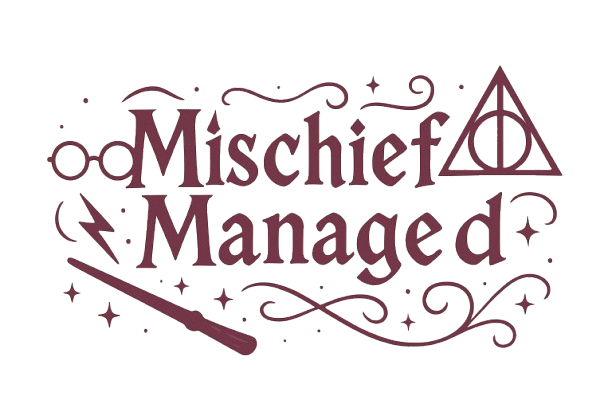